In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , LabelEncoder # for binary & labels & for nomalization
from sklearn.model_selection import train_test_split # for training and testing
from sklearn.linear_model import LinearRegression # calling the algorithm
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error # evalution

In [3]:
df = pd.read_csv(r"C:\Users\Shivam Yadav\Downloads\Housing_Dataset.csv")


In [4]:
df.head()

,Area,Bedrooms,Bathrooms,Age,Distance,SafetyScore,Price
0,2095.0,5.0,2.0,5.0,2.0,8.0,1005296.0
1,2600.0,1.0,2.0,11.0,23.0,7.0,876801.0
2,1350.0,5.0,1.0,5.0,6.0,9.0,742155.0
3,1712.0,1.0,3.0,16.0,18.0,4.0,606531.0
4,1062.0,NaN,2.0,11.0,27.0,5.0,381880.0


In [5]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Distance', 'SafetyScore',
       'Price'],
      dtype='object')

In [6]:
df.isnull().sum().reset_index()

,index,0
0,Area,52
1,Bedrooms,64
2,Bathrooms,51
3,Age,48
4,Distance,42
5,SafetyScore,52
6,Price,45


In [7]:
# dropping entire row where price is null
df = df.dropna(subset=['Price'])


In [8]:
# Filling remaining nulls with median
df.fillna(df.median(), inplace=True)

In [9]:
df.isnull().sum().reset_index()

,index,0
0,Area,0
1,Bedrooms,0
2,Bathrooms,0
3,Age,0
4,Distance,0
5,SafetyScore,0
6,Price,0


In [10]:
#Removing duplicated values
df_new=df.drop_duplicates()

In [11]:
df_new.duplicated().sum()

np.int64(0)

In [12]:
df_new.head()

,Area,Bedrooms,Bathrooms,Age,Distance,SafetyScore,Price
0,2095.0,5.0,2.0,5.0,2.0,8.0,1005296.0
1,2600.0,1.0,2.0,11.0,23.0,7.0,876801.0
2,1350.0,5.0,1.0,5.0,6.0,9.0,742155.0
3,1712.0,1.0,3.0,16.0,18.0,4.0,606531.0
4,1062.0,3.0,2.0,11.0,27.0,5.0,381880.0


## Checing Co-relation

In [13]:
df_new.corr()

,Area,Bedrooms,Bathrooms,Age,Distance,SafetyScore,Price
Area,1.000000,0.031617,-0.015344,0.012464,-0.005769,0.005151,0.898767
Bedrooms,0.031617,1.000000,0.051419,-0.030901,-0.041734,0.011386,0.336314
Bathrooms,-0.015344,0.051419,1.000000,0.024655,0.023072,-0.015898,0.127525
Age,0.012464,-0.030901,0.024655,1.000000,0.003275,-0.001176,-0.062155
Distance,-0.005769,-0.041734,0.023072,0.003275,1.000000,0.021926,-0.122417
SafetyScore,0.005151,0.011386,-0.015898,-0.001176,0.021926,1.000000,0.110724
Price,0.898767,0.336314,0.127525,-0.062155,-0.122417,0.110724,1.000000


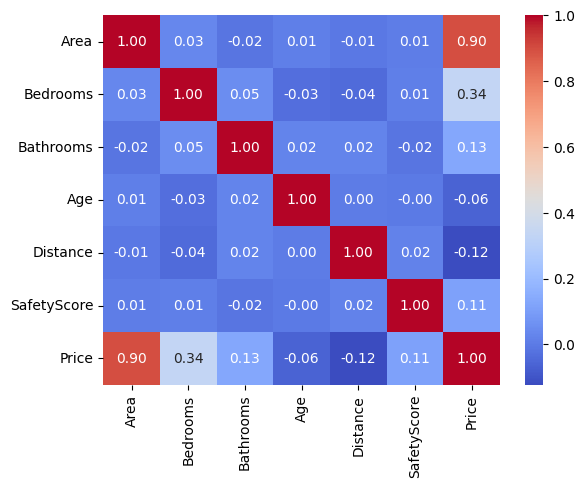

In [14]:
sns.heatmap(df_new.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

## Splitting the columns in to X and Y variable

In [15]:
X=df_new.drop("Price",axis="columns") # Independent Variable
y=df_new["Price"] # DEP VAR (Target Variable)

In [16]:
X.head()

,Area,Bedrooms,Bathrooms,Age,Distance,SafetyScore
0,2095.0,5.0,2.0,5.0,2.0,8.0
1,2600.0,1.0,2.0,11.0,23.0,7.0
2,1350.0,5.0,1.0,5.0,6.0,9.0
3,1712.0,1.0,3.0,16.0,18.0,4.0
4,1062.0,3.0,2.0,11.0,27.0,5.0


In [17]:
y.head().reset_index()

,index,Price
0,0,1005296.0
1,1,876801.0
2,2,742155.0
3,3,606531.0
4,4,381880.0


## Splitting data for train and test

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

## Data scalling

In [19]:
ss=StandardScaler()

In [20]:
ss

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [21]:
X_trainS=ss.fit_transform(X_train)
X_testS=ss.fit_transform(X_test)

In [22]:
X_trainS


array([[-0.49677169,  0.        ,  1.32994348, -1.37411717,  1.23447263,
        -0.56756294],
       [ 0.02771194,  0.71490009,  1.32994348, -0.29752704, -1.69797963,
         1.62081088],
       [-1.72246713,  1.42980018,  1.32994348, -1.13487492, -0.64229681,
         0.52662397],
       ...,
       [-1.32767918,  0.71490009,  1.32994348, -0.89563267, -0.40770063,
        -1.66174985],
       [-0.65069623,  0.        ,  0.04268954,  0.06133634, -0.29040254,
         0.161895  ],
       [ 0.62488217,  0.        , -1.24456439,  0.42019972,  0.06149173,
        -1.66174985]], shape=(784, 6))

## Modular Evaluation Linear Regression

In [23]:
lr=LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
lr.fit(X_trainS, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
print(mean_absolute_error(y_test,lr.predict(X_testS)))
print(mean_squared_error(y_test,lr.predict(X_testS)))
print(np.sqrt(mean_squared_error(y_test,lr.predict(X_testS))))
r2 = r2_score(y_test, lr.predict(X_testS))

45692.69720618252
5067961445.458746
71189.61613507089


In [26]:
print("The R2_Score is:",r2)

The R2_Score is: 0.8846088594451611
